<a href="https://colab.research.google.com/github/GhariebML/ICAIL_Final_Graduation_Project_Random_Password_Maker/blob/main/ICAIL_Final_Graduation_Project_Random_Password_Maker_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ICAIL Final Graduation Project_Random Password Maker(G8)

##Project Overview

In [ ]:
# Random Password Strength Analysis & Modeling
# Author: 'Mohamed Gharieb
# Dataset: Kaggle - "passwords_dataset"
# Goal: Analyze password characteristics and build models to classify strength (Weak / Medium / Strong)

#1. Environment Setup
##1.1_ Importing Libraries & Global Settings


In [61]:
# 1. Imports & Settings
import random
import string
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import permutation_importance

sns.set(style="whitegrid")
RANDOM_STATE = 30

###1.2 Colab & Storage Configuration

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

##2. Data Loading & Initial Exploration
###2.1 Dataset Loading




In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jeffersonvalandro/password-dataset")

print("Path to dataset files:", path)

100%|██████████| 113k/113k [00:00<00:00, 16.8MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/jeffersonvalandro/password-dataset/versions/1


In [37]:
data = pd.read_csv('/root/.cache/kagglehub/datasets/jeffersonvalandro/password-dataset/versions/1/passwords_dataset.csv')

###2.2 Data Structure & Quality Check

In [4]:
data.head()

,Password,Has Lowercase,Has Uppercase,Has Special Character,Length,Strength
0,<%r?.,True,False,True,5,Weak
1,l(d_l,True,False,True,5,Weak
2,"|+Z)kDTRYo:q{""(",True,True,True,15,Strong
3,gwcNB[oS5!n%OPJ,True,True,True,15,Strong
4,^vXjCCP6,True,True,True,8,Strong


In [38]:
# 3. Basic Inspection

data.info()
print("\nMissing values per column:")
print(data.isnull().sum())

print("\nStrength value counts:")
print(data["Strength"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Password               10000 non-null  object
 1   Has Lowercase          10000 non-null  bool  
 2   Has Uppercase          10000 non-null  bool  
 3   Has Special Character  10000 non-null  bool  
 4   Length                 10000 non-null  int64 
 5   Strength               10000 non-null  object
dtypes: bool(3), int64(1), object(2)
memory usage: 263.8+ KB

Missing values per column:
Password                 0
Has Lowercase            0
Has Uppercase            0
Has Special Character    0
Length                   0
Strength                 0
dtype: int64

Strength value counts:
Strength
Strong    5952
Weak      2197
Medium    1851
Name: count, dtype: int64


In [6]:
data.shape

(10000, 6)

In [7]:
data.describe()

,Length
count,10000.000000
mean,9.420600
std,4.015259
min,3.000000
25%,6.000000
50%,9.000000
75%,13.000000
max,16.000000


In [8]:
# Check for missing values
data.isnull().sum()

,0
Password,0
Has Lowercase,0
Has Uppercase,0
Has Special Character,0
Length,0
Strength,0


In [9]:
data['Strength'].value_counts()

,count
Strength,
Strong,5952
Weak,2197
Medium,1851


###2.3 Target Encoding (Strength → Strength_encoded)

In [39]:
# 4. Encode Target (Strength)
# We encode to give categories (Weak, Medium, Strong) a numerical value (0, 1, 2) to use for modeling

label_encoder = LabelEncoder()
data["Strength_encoded"] = label_encoder.fit_transform(data["Strength"])

print("Label mapping:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))
data[["Strength", "Strength_encoded"]].head()

Label mapping: {'Medium': np.int64(0), 'Strong': np.int64(1), 'Weak': np.int64(2)}


,Strength,Strength_encoded
0,Weak,2
1,Weak,2
2,Strong,1
3,Strong,1
4,Strong,1


---
##4. Exploratory Data Analysis (EDA)
---





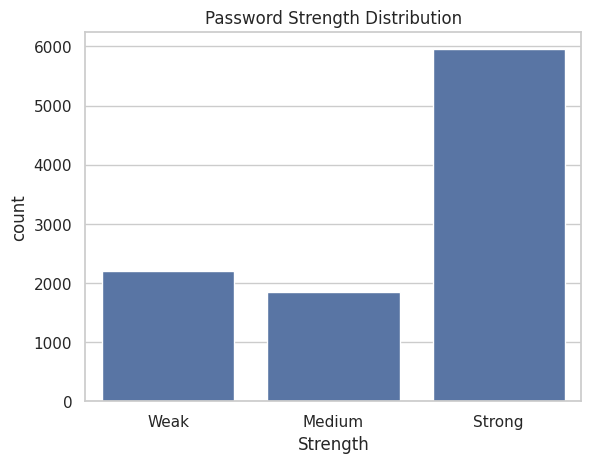

In [40]:
# 4.1 Distribution of Strength

plt.figure()
sns.countplot(x="Strength", data=data, order=["Weak", "Medium", "Strong"])
plt.title("Password Strength Distribution")
plt.show()

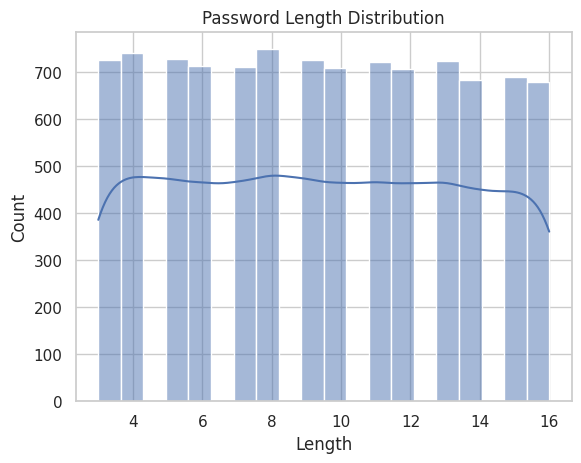

In [41]:
# 4.2 Password Length Distribution

plt.figure()
sns.histplot(data["Length"], bins=20, kde=True)
plt.title("Password Length Distribution")
plt.xlabel("Length")
plt.ylabel("Count")
plt.show()

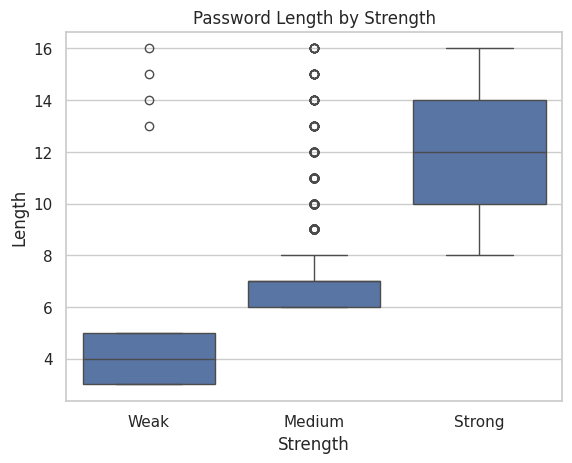

In [42]:
# 4.3 Length vs Strength

plt.figure()
sns.boxplot(x="Strength", y="Length", data=data, order=["Weak", "Medium", "Strong"])
plt.title("Password Length by Strength")
plt.show()

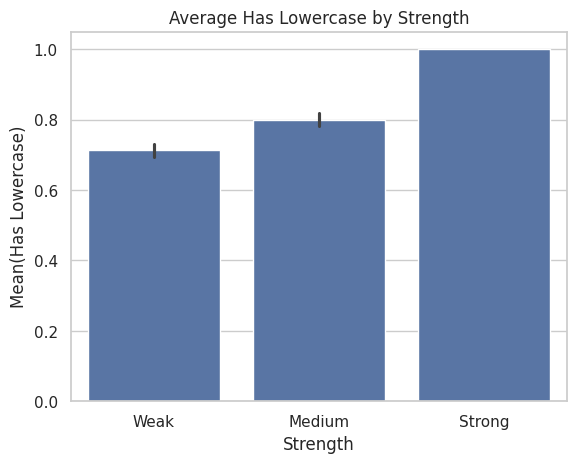

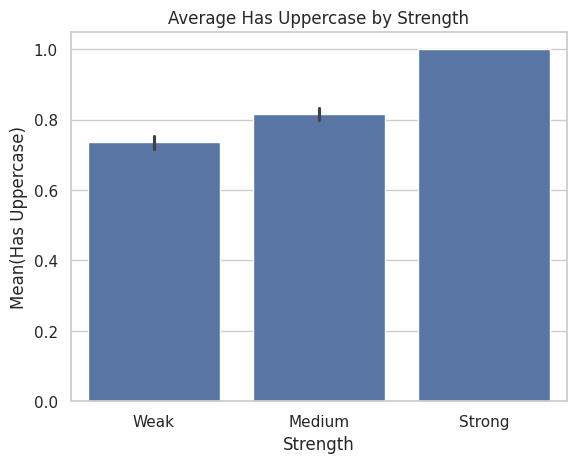

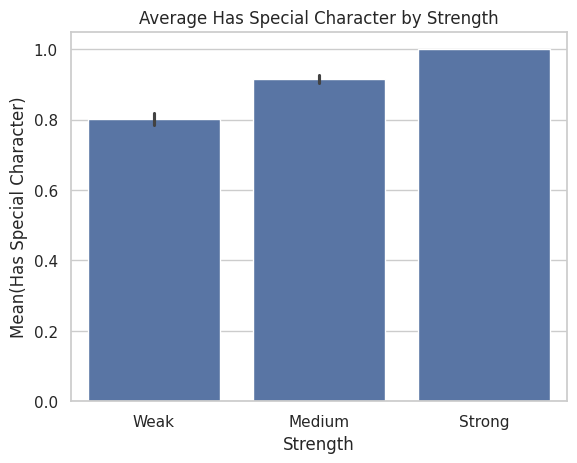

In [43]:
# 4.4 Proportion of features by Strength

binary_cols = ["Has Lowercase", "Has Uppercase", "Has Special Character"]
for col in binary_cols:
    plt.figure()
    sns.barplot(
        x="Strength",
        y=col,
        data=data,
        estimator=np.mean,
        order=["Weak", "Medium", "Strong"]
    )
    plt.title(f"Average {col} by Strength")
    plt.ylabel(f"Mean({col})")
    plt.show()

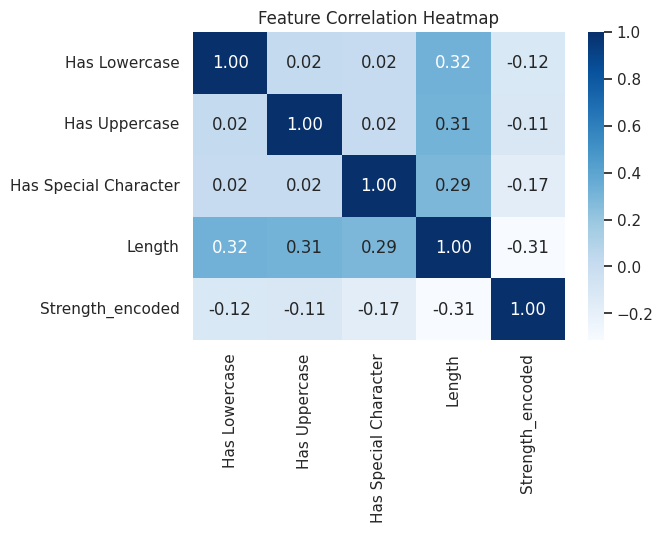

In [44]:
# 4.5 Correlation Heatmap

features_for_corr = ["Has Lowercase", "Has Uppercase", "Has Special Character", "Length", "Strength_encoded"]
corr = data[features_for_corr].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()


##5. Modeling: Baseline & Advanced Models
###5.1 Feature Selection & Train/Test Split

In [45]:
# 6. Feature Matrix (X) & Target (y)

feature_cols = ["Has Lowercase", "Has Uppercase", "Has Special Character", "Length"]
X = data[feature_cols]
y = data["Strength_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

X_train.shape, X_test.shape

((8000, 4), (2000, 4))

In [12]:
# Split the data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=30)

###5.2 K-Nearest Neighbors (KNN) Classifier

In [62]:
# KNN Model - Training

K = 7

knn = KNeighborsClassifier(
    n_neighbors=K,
    weights="distance",   # 'uniform' or 'distance'
    metric="minkowski",   # (p=2 => Euclidean)
    p=2,
    n_jobs=-1
)

knn.fit(X_train, y_train)


KNeighborsClassifier(n_jobs=-1, n_neighbors=7, weights='distance')

In [63]:
# Evaluation on Test Set (KNN)

y_pred_knn = knn.predict(X_test)

acc_knn = accuracy_score(y_test, y_pred_knn)
prec_knn, rec_knn, f1_knn, _ = precision_recall_fscore_support(
    y_test, y_pred_knn, average="weighted"
)

print(f"KNN (k={K}) - Accuracy: {acc_knn:.4f}")
print(f"KNN (k={K}) - Precision: {prec_knn:.4f}")
print(f"KNN (k={K}) - Recall:    {rec_knn:.4f}")
print(f"KNN (k={K}) - F1-score:  {f1_knn:.4f}\n")

print("Classification Report (KNN):")
print(classification_report(y_test, y_pred_knn, target_names=label_encoder.classes_))

KNN (k=7) - Accuracy: 1.0000
KNN (k=7) - Precision: 1.0000
KNN (k=7) - Recall:    1.0000
KNN (k=7) - F1-score:  1.0000

Classification Report (KNN):
              precision    recall  f1-score   support

      Medium       1.00      1.00      1.00       370
      Strong       1.00      1.00      1.00      1191
        Weak       1.00      1.00      1.00       439

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [64]:
# 5.3 5-fold Cross-Validation (KNN)

knn_cv_scores = cross_val_score(
    knn,
    X,
    y,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print(f"KNN (k={K}) CV Accuracy: {knn_cv_scores.mean():.4f} ± {knn_cv_scores.std():.4f}")

KNN (k=7) CV Accuracy: 0.9994 ± 0.0005


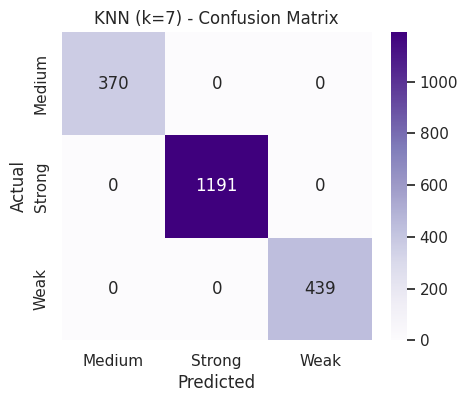

In [65]:
# Confusion Matrix (KNN)

cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_knn_df = pd.DataFrame(
    cm_knn,
    index=label_encoder.classes_,
    columns=label_encoder.classes_
)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_knn_df, annot=True, fmt="d", cmap="Purples")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"KNN (k={K}) - Confusion Matrix")
plt.show()


### 5.3 Logistic Regression Model

In [46]:
# Logistic Regression model
log_reg_model = LogisticRegression(max_iter=1000)
log_reg_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [47]:
print("Actual iterations used:", log_reg_model.n_iter_)

Actual iterations used: [141]


In [48]:
# Predictions for Logistic Regression
y_pred_log_reg = log_reg_model.predict(X_test)
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)

In [49]:
# Evaluate additional metrics for Logistic Regression
precision_log_reg, recall_log_reg, f1_log_reg, _ = precision_recall_fscore_support(y_test, y_pred_log_reg, average='weighted')

In [50]:
# Print the evaluation results
print(f"Logistic Regression Accuracy: {accuracy_log_reg:.4f}")
print(f"Logistic Regression Precision: {precision_log_reg:.4f}")
print(f"Logistic Regression Recall: {recall_log_reg:.4f}")
print(f"Logistic Regression F1-score: {f1_log_reg:.4f}")

Logistic Regression Accuracy: 0.9985
Logistic Regression Precision: 0.9985
Logistic Regression Recall: 0.9985
Logistic Regression F1-score: 0.9985


In [54]:
# Cross-validation for Logistic Regression (accuracy)
# 7.3 5-fold Cross-Validation (Accuracy)

lr_cv_scores = cross_val_score(
   log_reg_model, X, y, cv=5, scoring="accuracy", n_jobs=-1
)
print(f"Logistic Regression CV Accuracy: {lr_cv_scores.mean():.4f} ± {lr_cv_scores.std():.4f}")
# 5-fold cross-validation

Logistic Regression CV Accuracy: 0.9970 ± 0.0009


In [52]:
# Print the cross-validation results
print(f"Logistic Regression Cross-Validation Accuracy: {log_reg_cv_scores.mean():.4f} ± {log_reg_cv_scores.std():.4f}")

Logistic Regression Cross-Validation Accuracy: 0.9970 ± 0.0009


###5.4 Random Forest model:

In [19]:
# Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=30)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=30)

In [20]:
# Predictions for Random Forest
y_pred_rf = rf_model.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

In [21]:
# Evaluate additional metrics for Random Forest
precision_rf, recall_rf, f1_rf, _ = precision_recall_fscore_support(y_test, y_pred_rf, average='weighted')

In [22]:
# Print the evaluation results
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print(f"Random Forest Precision: {precision_rf:.4f}")
print(f"Random Forest Recall: {recall_rf:.4f}")
print(f"Random Forest F1-score: {f1_rf:.4f}")

Random Forest Accuracy: 1.0000
Random Forest Precision: 1.0000
Random Forest Recall: 1.0000
Random Forest F1-score: 1.0000


In [23]:
# Cross-validation for Random Forest (accuracy)
rf_cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='accuracy')  # 5-fold cross-validation

In [24]:
# Print the cross-validation results
print(f"Random Forest Cross-Validation Accuracy: {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}")

Random Forest Cross-Validation Accuracy: 0.9996 ± 0.0002


##6. Model Interpretation & Feature Importance
###6.1 Confusion Matrices

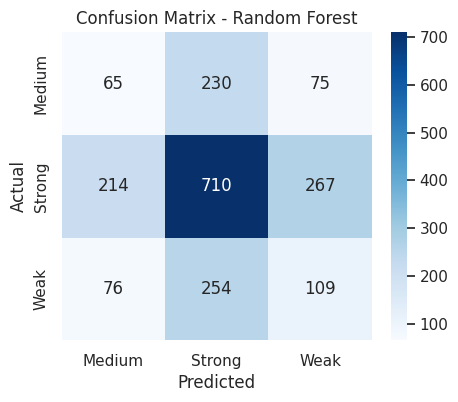

In [55]:
# 6. Confusion Matrix for Random Forest

cm = confusion_matrix(y_test, y_pred_rf)
cm_df = pd.DataFrame(cm, index=label_encoder.classes_, columns=label_encoder.classes_)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

##6.2 Permutation Feature Importance (Random Forest)

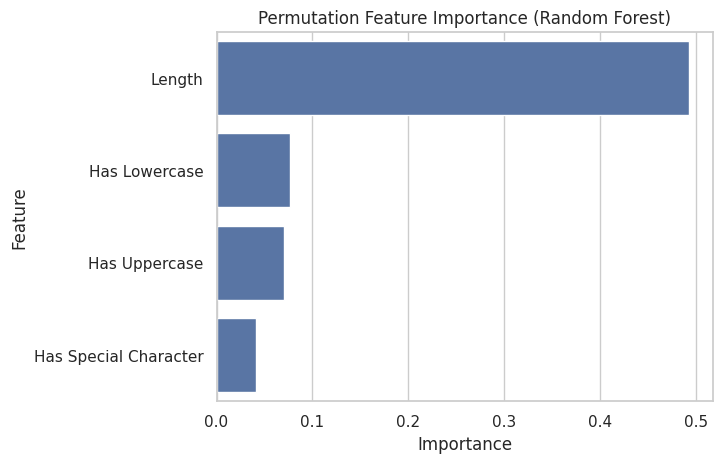

,0
Length,0.49245
Has Lowercase,0.07620
Has Uppercase,0.07088
Has Special Character,0.04139


In [57]:
# 10. Feature Importance (Permutation)

result = permutation_importance(
    rf_model, X, y, n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
)

importances = pd.Series(
    result.importances_mean,
    index=feature_cols
).sort_values(ascending=False)

plt.figure()
sns.barplot(x=importances.values, y=importances.index)
plt.title("Permutation Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

importances

##7. Password Strength Prediction Utilities

In [59]:
# 11. Helper: Extract features from raw password

def extract_features_from_password(password: str) -> pd.DataFrame:
    features = {
        "Has Lowercase": int(any(c.islower() for c in password)),
        "Has Uppercase": int(any(c.isupper() for c in password)),
        "Has Special Character": int(any(not c.isalnum() for c in password)),
        "Length": len(password)
    }
    return pd.DataFrame([features])

def predict_strength(password: str, model=rf_model, label_encoder=label_encoder):
    X_pw = extract_features_from_password(password)
    y_num = model.predict(X_pw)[0]
    label = label_encoder.inverse_transform([y_num])[0]
    return label

# Example
test_pw = "Abc!1234"
print(test_pw, "=>", predict_strength(test_pw))

Abc!1234 => Strong


In [69]:
# Model Comparison Summary

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", f"KNN (k={K})"],
    "Accuracy": [accuracy_log_reg, accuracy_rf, acc_knn],
    "F1_weighted": [f1_log_reg, f1_rf, f1_knn]
})

results

,Model,Accuracy,F1_weighted
0,Logistic Regression,0.9985,0.998498
1,Random Forest,1.0000,1.000000
2,KNN (k=7),1.0000,1.000000


##8. Interactive Application (UI)


###8.1 Password Strength Checker (Multi-Model)


In [70]:
# ==========================================================
# 1. Password Strength Checker UI (LogReg + RF + KNN)
# ==========================================================

class PasswordStrengthChecker:
    """
    Interactive widget-based password strength checker.

    - Takes a dictionary of trained models (e.g. Logistic Regression, Random Forest, KNN).
    - Uses the same feature extraction pipeline as in model training.
    - Displays predictions with a clean bilingual (EN/AR) interface.
    """

    def __init__(self, models: dict, label_encoder: LabelEncoder):
        self.models = models
        self.label_encoder = label_encoder

        self.style_map = {
            "Weak":   {"color": "#e53935", "emoji": "😞"},
            "Medium": {"color": "#fb8c00", "emoji": "😐"},
            "Strong": {"color": "#43a047", "emoji": "💪"},
        }

        self._build_widgets()

    # ---------- Core logic ----------

    @staticmethod
    def _extract_features(password: str) -> pd.DataFrame:
        """Extracts model-ready features from a raw password string."""
        features = {
            "Has Lowercase": int(any(c.islower() for c in password)),
            "Has Uppercase": int(any(c.isupper() for c in password)),
            "Has Special Character": int(any(not c.isalnum() for c in password)),
            "Length": len(password),
        }
        return pd.DataFrame([features])

    def check_password_strength(self, password: str) -> dict:
        """Return predicted strength label for each model."""
        X_pw = self._extract_features(password)
        predictions = {}

        for name, model in self.models.items():
            pred_num = model.predict(X_pw)[0]
            pred_label = self.label_encoder.inverse_transform([pred_num])[0]
            predictions[name] = pred_label

        return predictions

    # ---------- UI construction ----------

    def _build_widgets(self):
        # Input widget
        self.password_input = widgets.Password(
            description="Password:",
            placeholder="Enter password / أدخل كلمة المرور",
            layout=widgets.Layout(width="60%"),
            style={"description_width": "initial"}
        )

        # Output areas
        self.summary_output = widgets.Output()
        self.models_output = widgets.Output()

        # Bind events
        self.password_input.observe(self._on_password_change, names="value")

        # High-level container
        self.container = widgets.VBox(
            [
                widgets.HTML(
                    "<h2 style='margin-bottom:4px;'>Password Strength Checker</h2>"
                    "<h4 style='margin-top:0;color:#555;'>"
                    "فاحص قوة كلمة المرور باستخدام نماذج التعلم الآلي"
                    "</h4>"
                ),
                self.password_input,
                self.summary_output,
                self.models_output,
            ]
        )

    def _on_password_change(self, change):
        password = change["new"]

        with self.summary_output:
            self.summary_output.clear_output()

        with self.models_output:
            self.models_output.clear_output()

            if not password:
                return

            predictions = self.check_password_strength(password)

            # إجمالي / ملخص
            strengths = list(predictions.values())
            # مثال بسيط: نعرض أقوى تقييم (Strong > Medium > Weak)
            order = {"Weak": 0, "Medium": 1, "Strong": 2}
            best_strength = max(strengths, key=lambda s: order.get(s, -1))
            style = self.style_map.get(best_strength, {})
            color = style.get("color", "black")
            emoji = style.get("emoji", "")

            with self.summary_output:
                display(
                    HTML(
                        f"<div style='margin-top:10px;margin-bottom:10px;'>"
                        f"<b>Overall Prediction (التقييم العام):</b> "
                        f"<span style='color:{color};font-size:1.1em;'>{best_strength} {emoji}</span>"
                        f"</div>"
                    )
                )

            # تفاصيل كل موديل
            display(
                HTML("<h4 style='margin-bottom:4px;'>Model-wise Predictions (توقعات كل نموذج):</h4>")
            )

            for model_name, strength in predictions.items():
                style = self.style_map.get(strength, {})
                color = style.get("color", "black")
                emoji = style.get("emoji", "")

                nice_name = model_name.replace("_", " ").title()
                display(
                    HTML(
                        f"<div style='margin-left:10px;'>"
                        f"<b>{nice_name}:</b> "
                        f"<span style='color:{color}'>{strength} {emoji}</span>"
                        f"</div>"
                    )
                )

    # ---------- Public API ----------

    def show(self):
        """Display the full checker UI."""
        display(self.container)

###8.2 Instantiate the Checker with All Models

In [72]:
# ==========================================================
# 2. Instantiate the Checker with All Models
# ==========================================================

models_dict = {
    "logistic_regression": log_reg_model,
    "random_forest": rf_model,
    "knn": knn,
}

checker = PasswordStrengthChecker(models=models_dict, label_encoder=label_encoder)
checker.show()

###8.3 Random Password Generator


In [73]:
# ==========================================================
# 3. Password Generator UI
# ==========================================================

style = {"description_width": "initial"}

total_chars = widgets.IntSlider(
    value=12,
    min=4,
    max=32,
    step=1,
    description="Total Length (الطول الكلي):",
    style=style,
    layout=widgets.Layout(width="60%"),
)

num_letters = widgets.IntSlider(
    value=8,
    min=0,
    max=32,
    step=1,
    description="Letters (الحروف):",
    style=style,
    layout=widgets.Layout(width="60%"),
)

num_numbers = widgets.IntSlider(
    value=2,
    min=0,
    max=32,
    step=1,
    description="Digits (الأرقام):",
    style=style,
    layout=widgets.Layout(width="60%"),
)

num_symbols = widgets.IntSlider(
    value=2,
    min=0,
    max=32,
    step=1,
    description="Symbols (الرموز):",
    style=style,
    layout=widgets.Layout(width="60%"),
)

generate_button = widgets.Button(
    description="Generate & Check (إنشاء وفحص)",
    button_style="success",
    icon="key",
    layout=widgets.Layout(width="60%"),
)

generator_output = widgets.Output()


def _sync_sliders(change):
    """اختياري: تقدر تضيف لوجيك يضمن المجموع = total_chars تلقائيًا إن حبيت."""
    pass  # تقدر تتركها أو تبني لوجيك متقدم هنا


def on_generate_button_clicked(b):
    with generator_output:
        generator_output.clear_output()

        if total_chars.value != num_letters.value + num_numbers.value + num_symbols.value:
            display(
                HTML(
                    "<span style='color:red;'>"
                    "Error: The sum of letters, digits, and symbols must equal the total length.<br>"
                    "خطأ: مجموع الحروف والأرقام والرموز يجب أن يساوي الطول الكلي."
                    "</span>"
                )
            )
            return

        # توليد الباسورد
        letters = random.choices(string.ascii_letters, k=num_letters.value)
        numbers = random.choices(string.digits, k=num_numbers.value)
        symbols = random.choices(string.punctuation, k=num_symbols.value)

        password_list = letters + numbers + symbols
        random.shuffle(password_list)
        generated_password = "".join(password_list)

        # تعبئة الـ checker تلقائيًا
        checker.password_input.value = generated_password

        display(
            HTML(
                f"<b>New Password Generated (كلمة مرور جديدة):</b> "
                f"<code style='font-size:1.1em;'>{generated_password}</code>"
            )
        )


generate_button.on_click(on_generate_button_clicked)

generator_ui = widgets.VBox(
    [
        widgets.HTML(
            "<h2 style='margin-bottom:4px;'>Password Generator</h2>"
            "<h4 style='margin-top:0;color:#555;'>مولد كلمات المرور العشوائية</h4>"
        ),
        total_chars,
        num_letters,
        num_numbers,
        num_symbols,
        generate_button,
        generator_output,
    ]
)

display(generator_ui)
checker.show()